TASK 2 : Sales Performance Analysis

A. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

B. Load the Dataset

In [6]:
import pandas as pd

df = pd.read_csv("superstore_final_dataset (1).csv", encoding='latin1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


5 rows × 21 columns

c. Understanding Data

In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   str    
 2   Order_Date     9800 non-null   str    
 3   Ship_Date      9800 non-null   str    
 4   Ship_Mode      9800 non-null   str    
 5   Customer_ID    9800 non-null   str    
 6   Customer_Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product_ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub_Category   9800 non-null   str    
 16  Product_Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


D. Cleaning Dataset

In [9]:
df = df.drop(columns=['Unnamed: 18','Unnamed: 19','Unnamed: 20'], errors='ignore')

In [10]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='str')

E. Converting Columns to Correct Type

In [13]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

In [14]:
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

F. Handling Missing Values

In [15]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [16]:
df = df.dropna(subset=['Sales'])

G. Creating Time Columns

In [17]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()

H. Creating KPIs

1. Total Revenue

In [18]:

total_revenue = df['Sales'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 2261536.7827


2. Average Order Value

In [19]:
total_orders = df['Order_ID'].nunique()
aov = total_revenue / total_orders
print("Average Order Value:", aov)

Average Order Value: 459.4751691791954


3. Total Order

In [20]:
print("Total Orders:", total_orders)


Total Orders: 4922


I. Regional Sales Analysis

In [24]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

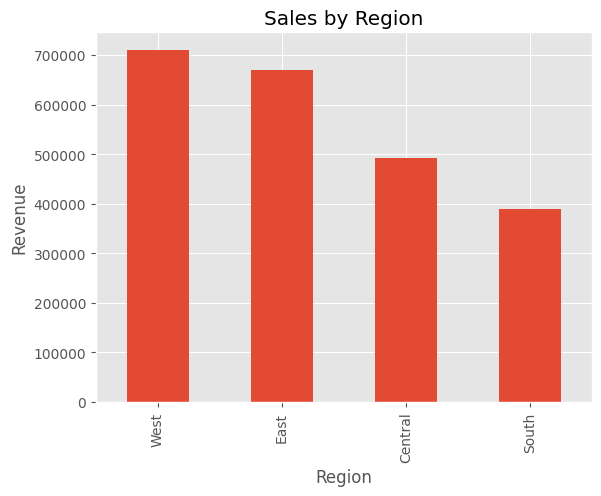

In [25]:
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

J. Sales by Category

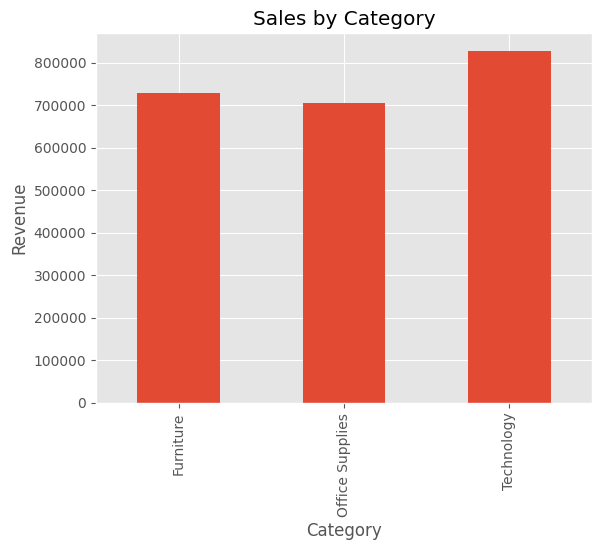

In [26]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Revenue")
plt.show()

K. Top 10 Best Selling Products

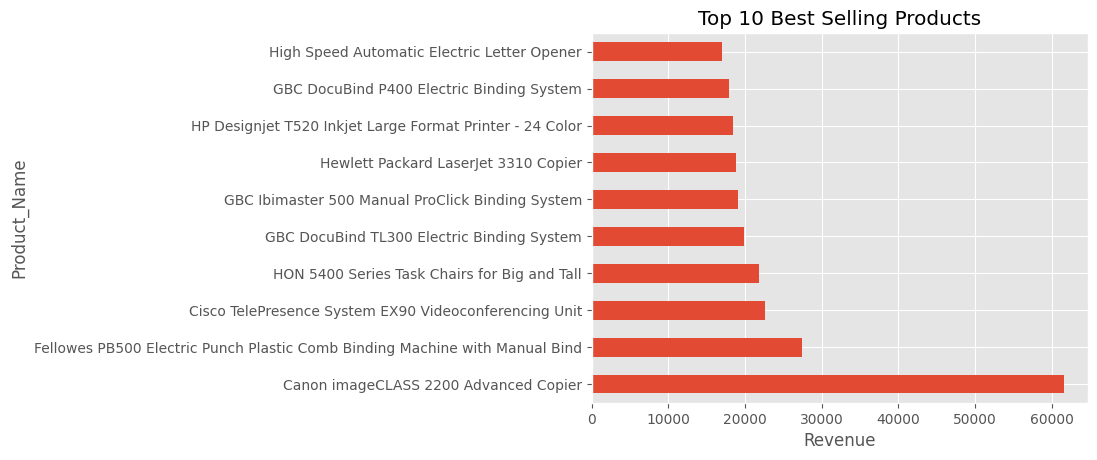

In [28]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh')
plt.title("Top 10 Best Selling Products")
plt.xlabel("Revenue")
plt.show()

L. Worst Performing Proudcts

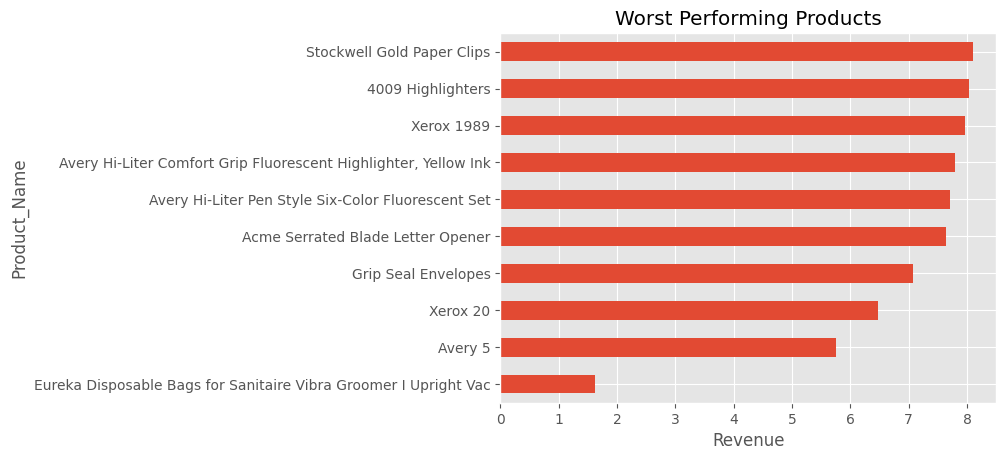

In [30]:
worst_products = df.groupby('Product_Name')['Sales'].sum().sort_values().head(10)
worst_products.plot(kind='barh')
plt.title("Worst Performing Products")
plt.xlabel("Revenue")
plt.show()

M. Monthly Sales Trend

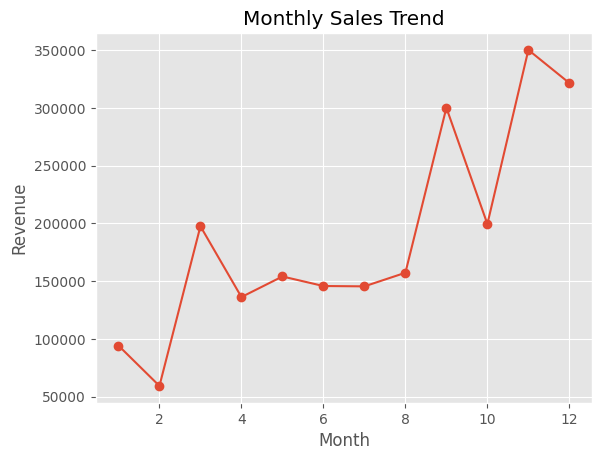

In [31]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

N. Sales By Customer Segment

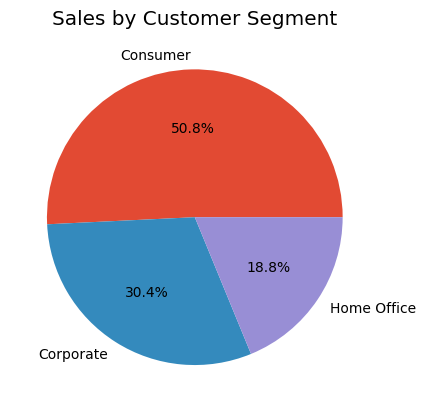

In [32]:
segment_sales = df.groupby('Segment')['Sales'].sum()
segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Customer Segment")
plt.show()

O. Key Business Insights

1. West region generates the highest revenue compared to other regions.

2. Technology category contributes the most to total sales.

3. A small number of products generate the majority of revenue.

4. Sales increase significantly during the last quarter of the year.

5. Consumer segment contributes the largest portion of revenue.

P. 5 Suggested Tactical Improvements

1. Focus marketing campaigns in high-performing regions to maximize revenue.

2. Increase inventory and promotion of top-selling products.

3. Improve marketing strategies for low-performing products.

4. Use seasonal sales patterns to launch discount campaigns during peak months.
5. Target the consumer segment with personalized offers and loyalty programs